# 3D Sound rendering Lab - show HRTF data

**Answers**

**Answer 1:** The function getNearestUCDpulse gives the HRTF of a given subject for a given azimuth and elevation. Since we do not have measurements for every possible position, it returns the closest one available in the database.

**Answer 2:** The sound is not filtered in the same way depending on where it comes from. The head and pinnae create diffraction, shadowing and reflection effects, which modify the signal at each ear. The HRTF depends on the azimuth and the elevation because the modifications are different depending on where the signal is coming from. 

**Answer 3:** Yes, there are differences between subjects. This can be explained by the fact that people do not have the same ear shape and the same head shape.

**Answer 4:** They have the same delay because we took azimuth = 0, so the source is at the same distance from both ears. If the azimuth is not equal to 0, the distance to the two ears becomes different, so the delay is not the same anymore.

### G. Richard, Feb. 2026

In [5]:
import os, sys, wave, struct

import numpy as np
from scipy.io import loadmat
import pyaudio
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from math import ceil

##  Load subject HRTF

In [6]:
subject3 = loadmat('subject_003/hrir_final.mat')
subject44 = loadmat('subject_044/hrir_final.mat')
subject65 = loadmat('subject_065/hrir_final.mat')
subject165 = loadmat('subject_165/hrir_final.mat')



In [17]:
SUBJECT = subject44

## Visualization of the HRTF database

### getNearestUCDpulse(azimuth, elevation, subject): Get the neareast HRTF given a position in space for a given subject
### Example: hrtf=getNearestUCDpulse(0, 0, subject3) stores in hrtf the HRTFs (left in hrtf[0]; right in hrt[1]) of subject3 at azimuth=0; elevation=0 

In [18]:
def getNearestUCDpulse(azimuth, elevation, subject):
    
    elmax = 49
    elindices = np.arange(elmax+1)
    elevations = -45 + 5.625*(elindices)
    azimuths = np.hstack([[-80, -65, -55],np.arange(-45, 50, 5),[55, 65, 80]])
    
    el = round((elevation+45)/5.625)
    el = np.clip(el, 0, elmax)
    elerr = el - ((elevation+45)/5.625)
    
    azim = np.argmin(np.abs(azimuths - azimuth))
    azerr = np.min(np.abs(azimuths - azimuth))
    
  #  print("Les parametres utilises pour la HRTF sont:")
  #  print("\t azimuths: {}".format(azimuths[azim]))
  #  print("\t elevation: {}".format(-45 + 5.625*el))
    
  #  print("\nLes indices sont:")
  #  print("\t azim: {}".format(azim))
  # print("\t el: {}".format(el))
    
    pulse = np.vstack([subject['hrir_l'][azim, el], subject['hrir_r'][azim, el]])
    
    return pulse

### Visualization program

#### Visualization of the HRTF database for a given subject
##### The visualisation consist in a figure with several subfigures:
##### On the top left, the figure displays all HRTF stacked in a matrix for the left ear with time in y-coordinate and angle in x-coordinate for a fixed elevation angle of 0 degree
##### On the top right, the figure displays all HRTF stacked in a matrix for the right ear with time in y-coordinate and angle in x-coordinate for a fixed elevation angle of 0 degree
##### On the bottom left, the figure displays the frequency response of all HRTF stacked in a matrix of the top left figure with frequency in y-coordinate and angle in x-coordinate
##### On the bottom right, the figure displays the frequency response of all HRTF stacked in a matrix of the top right figure with frequency in y-coordinate and angle in x-coordinate;

In [19]:
def visualisation_hrtf_database(SUBJECT, fs=44100):
    
    # -------------------------------------------------------
    # 1. Define azimuth grid (same as in getNearestUCDpulse)
    # -------------------------------------------------------
    azimuths = np.hstack([
        [-80, -65, -55],
        np.arange(-45, 50, 5),
        [55, 65, 80]
    ])
    
    elevation = 0  # fixed elevation
    
    # -------------------------------------------------------
    # 2. Retrieve HRIR using getNearestUCDpulse
    # -------------------------------------------------------
    hrir_left_list = []
    hrir_right_list = []
    
    for az in azimuths:
        hrir_l, hrir_r = getNearestUCDpulse(az, elevation, SUBJECT)
        hrir_left_list.append(hrir_l)
        hrir_right_list.append(hrir_r)
    
    hrir_left = np.array(hrir_left_list)    # shape (n_az, n_samples)
    hrir_right = np.array(hrir_right_list)
    
    n_az, n_samples = hrir_left.shape
    
    # -------------------------------------------------------
    # 3. Time-domain matrices
    # -------------------------------------------------------
    left_time = hrir_left.T      # (n_samples, n_az)
    right_time = hrir_right.T
    
    time_axis = np.arange(n_samples) / fs
    
    # -------------------------------------------------------
    # 4. Frequency-domain matrices
    # -------------------------------------------------------
    freq_axis = np.fft.rfftfreq(n_samples, 1/fs)
    
    left_freq = np.abs(np.fft.rfft(left_time, axis=0))
    right_freq = np.abs(np.fft.rfft(right_time, axis=0))
    
    eps = 1e-12
    left_freq_db = 20 * np.log10(left_freq + eps)
    right_freq_db = 20 * np.log10(right_freq + eps)
    
    # -------------------------------------------------------
    # 5. Plotting
    # -------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    
    # ---- Top Left : Left ear (time domain)
    im1 = axs[0, 0].imshow(
        left_time,
        aspect='auto',
        origin='lower',
        extent=[azimuths[0], azimuths[-1],
                time_axis[0], time_axis[-1]]
    )
    axs[0, 0].set_title("Left Ear - Time Domain (Elevation 0°)")
    axs[0, 0].set_xlabel("Azimuth (deg)")
    axs[0, 0].set_ylabel("Time (s)")
    fig.colorbar(im1, ax=axs[0, 0])
    
    # ---- Top Right : Right ear (time domain)
    im2 = axs[0, 1].imshow(
        right_time,
        aspect='auto',
        origin='lower',
        extent=[azimuths[0], azimuths[-1],
                time_axis[0], time_axis[-1]]
    )
    axs[0, 1].set_title("Right Ear - Time Domain (Elevation 0°)")
    axs[0, 1].set_xlabel("Azimuth (deg)")
    axs[0, 1].set_ylabel("Time (s)")
    fig.colorbar(im2, ax=axs[0, 1])
    
    # ---- Bottom Left : Left ear (frequency domain)
    im3 = axs[1, 0].imshow(
        left_freq_db,
        aspect='auto',
        origin='lower',
        extent=[azimuths[0], azimuths[-1],
                freq_axis[0], freq_axis[-1]]
    )
    axs[1, 0].set_title("Left Ear - Frequency Domain (Elevation 0°)")
    axs[1, 0].set_xlabel("Azimuth (deg)")
    axs[1, 0].set_ylabel("Frequency (Hz)")
    fig.colorbar(im3, ax=axs[1, 0])
    
    # ---- Bottom Right : Right ear (frequency domain)
    im4 = axs[1, 1].imshow(
        right_freq_db,
        aspect='auto',
        origin='lower',
        extent=[azimuths[0], azimuths[-1],
                freq_axis[0], freq_axis[-1]]
    )
    axs[1, 1].set_title("Right Ear - Frequency Domain (Elevation 0°)")
    axs[1, 1].set_xlabel("Azimuth (deg)")
    axs[1, 1].set_ylabel("Frequency (Hz)")
    fig.colorbar(im4, ax=axs[1, 1])
    
    plt.tight_layout()
    plt.show()

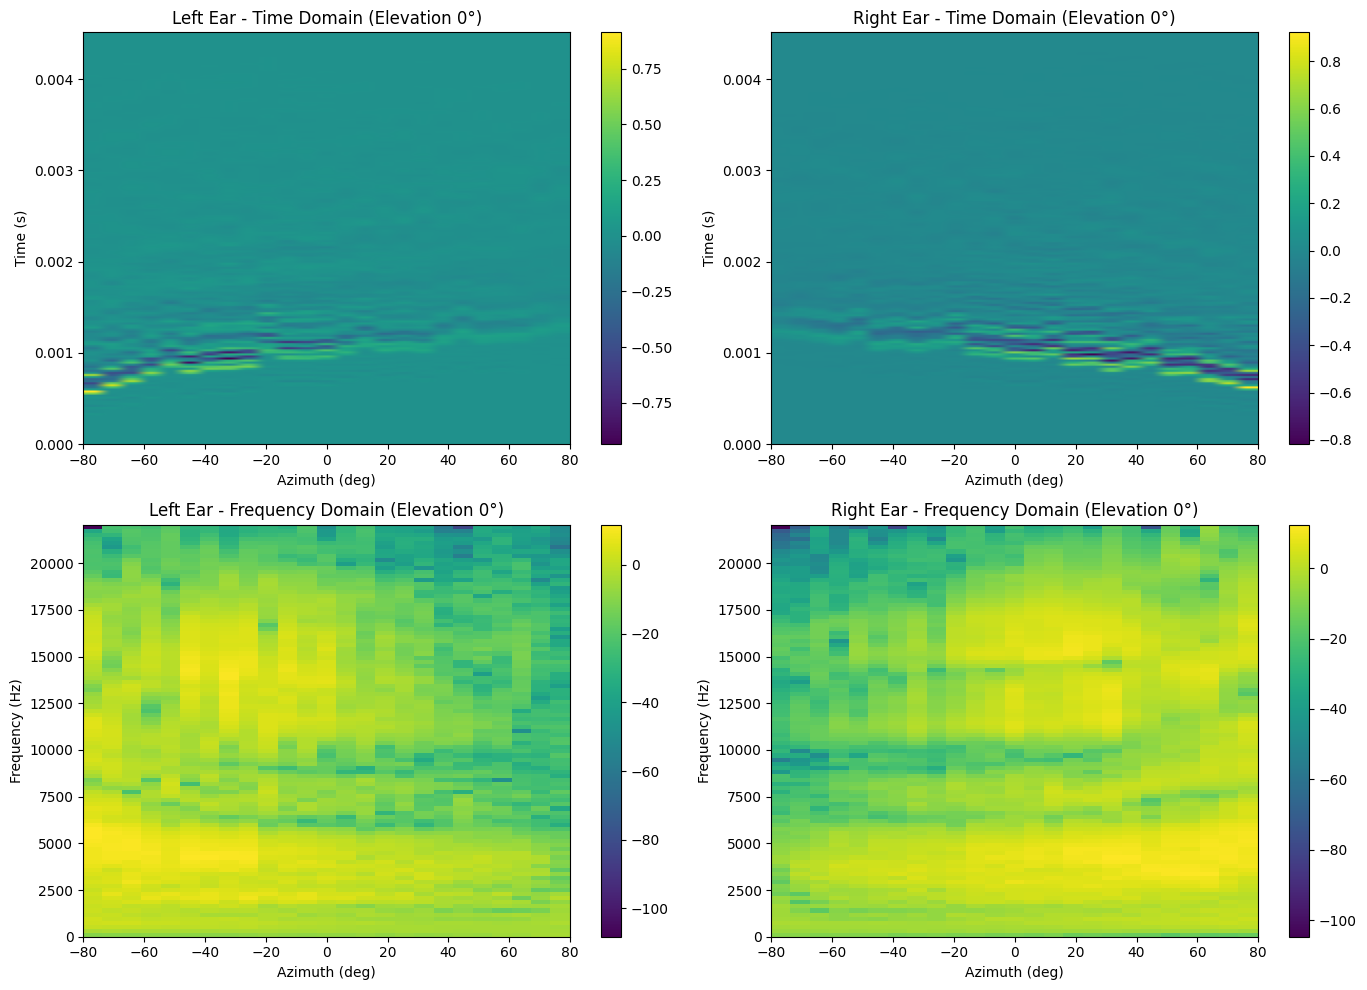

In [20]:
visualisation_hrtf_database(SUBJECT)

In [21]:
def visualisation_elevation(SUBJECT, fs=44100):
    
    # -------------------------------------------------------
    # 1. Define elevation grid (same as in your notebook)
    # -------------------------------------------------------
    elmax = 49
    elevations = -45 + 5.625 * np.arange(elmax + 1)
    
    azimuth = 0  # fixed azimuth
    
    # -------------------------------------------------------
    # 2. Retrieve HRIR using getNearestUCDpulse
    # -------------------------------------------------------
    hrir_left_list = []
    hrir_right_list = []
    
    for el in elevations:
        hrir_l, hrir_r = getNearestUCDpulse(azimuth, el, SUBJECT)
        hrir_left_list.append(hrir_l)
        hrir_right_list.append(hrir_r)
    
    hrir_left = np.array(hrir_left_list)    # (n_el, n_samples)
    hrir_right = np.array(hrir_right_list)
    
    n_el, n_samples = hrir_left.shape
    
    # -------------------------------------------------------
    # 3. Time-domain matrices
    # -------------------------------------------------------
    left_time = hrir_left.T      # (n_samples, n_el)
    right_time = hrir_right.T
    
    time_axis = np.arange(n_samples) / fs
    
    # -------------------------------------------------------
    # 4. Frequency-domain matrices
    # -------------------------------------------------------
    freq_axis = np.fft.rfftfreq(n_samples, 1/fs)
    
    left_freq = np.abs(np.fft.rfft(left_time, axis=0))
    right_freq = np.abs(np.fft.rfft(right_time, axis=0))
    
    eps = 1e-12
    left_freq_db = 20 * np.log10(left_freq + eps)
    right_freq_db = 20 * np.log10(right_freq + eps)
    
    # -------------------------------------------------------
    # 5. Plotting
    # -------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    
    # ---- Top Left : Left ear (time domain)
    im1 = axs[0, 0].imshow(
        left_time,
        aspect='auto',
        origin='lower',
        extent=[elevations[0], elevations[-1],
                time_axis[0], time_axis[-1]]
    )
    axs[0, 0].set_title("Left Ear - Time Domain (Azimuth 0°)")
    axs[0, 0].set_xlabel("Elevation (deg)")
    axs[0, 0].set_ylabel("Time (s)")
    fig.colorbar(im1, ax=axs[0, 0])
    
    # ---- Top Right : Right ear (time domain)
    im2 = axs[0, 1].imshow(
        right_time,
        aspect='auto',
        origin='lower',
        extent=[elevations[0], elevations[-1],
                time_axis[0], time_axis[-1]]
    )
    axs[0, 1].set_title("Right Ear - Time Domain (Azimuth 0°)")
    axs[0, 1].set_xlabel("Elevation (deg)")
    axs[0, 1].set_ylabel("Time (s)")
    fig.colorbar(im2, ax=axs[0, 1])
    
    # ---- Bottom Left : Left ear (frequency domain)
    im3 = axs[1, 0].imshow(
        left_freq_db,
        aspect='auto',
        origin='lower',
        extent=[elevations[0], elevations[-1],
                freq_axis[0], freq_axis[-1]]
    )
    axs[1, 0].set_title("Left Ear - Frequency Domain (Azimuth 0°)")
    axs[1, 0].set_xlabel("Elevation (deg)")
    axs[1, 0].set_ylabel("Frequency (Hz)")
    fig.colorbar(im3, ax=axs[1, 0])
    
    # ---- Bottom Right : Right ear (frequency domain)
    im4 = axs[1, 1].imshow(
        right_freq_db,
        aspect='auto',
        origin='lower',
        extent=[elevations[0], elevations[-1],
                freq_axis[0], freq_axis[-1]]
    )
    axs[1, 1].set_title("Right Ear - Frequency Domain (Azimuth 0°)")
    axs[1, 1].set_xlabel("Elevation (deg)")
    axs[1, 1].set_ylabel("Frequency (Hz)")
    fig.colorbar(im4, ax=axs[1, 1])
    
    plt.tight_layout()
    plt.show()

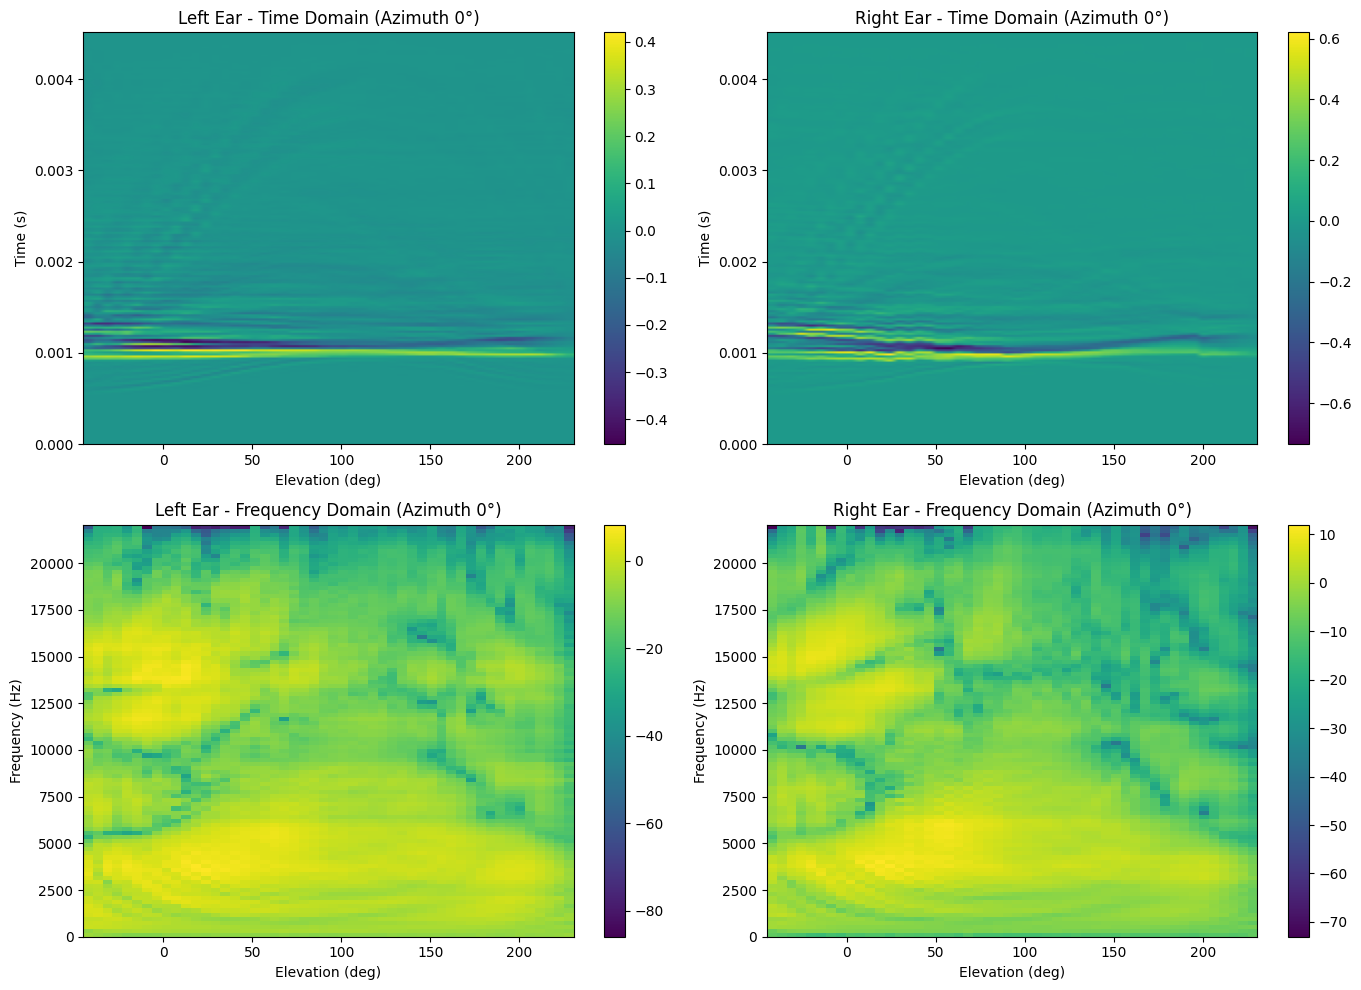

In [22]:
visualisation_elevation(SUBJECT)

In [32]:
hrtf=getNearestUCDpulse(0, 0, SUBJECT)

#### plot the hrtf for left ear

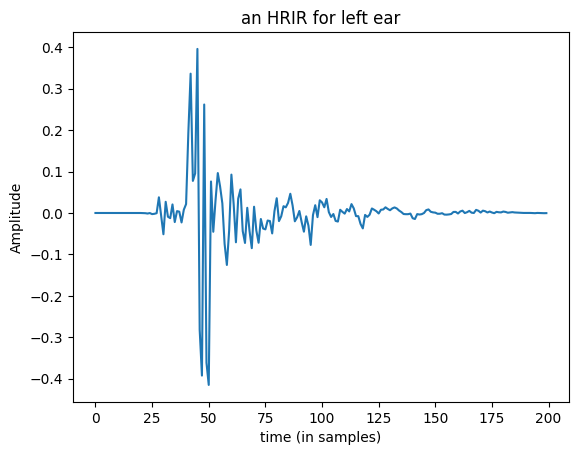

In [33]:
plt.plot(hrtf[0]);

plt.xlabel("time (in samples)")
plt.ylabel("Amplitude")
plt.title("an HRIR for left ear")

plt.show()

#### plot the hrtf for right ear

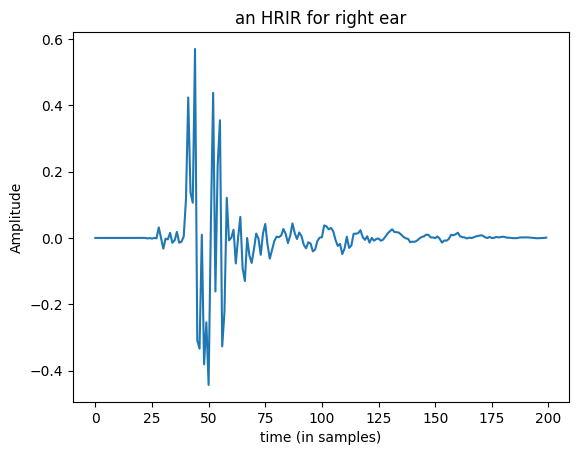

In [34]:
plt.plot(hrtf[1]);
plt.xlabel("time (in samples)")
plt.ylabel("Amplitude")
plt.title("an HRIR for right ear")

plt.show()
